<a href="https://colab.research.google.com/github/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_seg_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with DICOM Segmentations in computational pathology


This tutorial is shared as part of the tutorials prepared by the Imaging Data Commons (IDC) team and available at https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks.

If you are new to IDC and DICOM for digital pathology applications, you may want to check out other introductory tutorials on this topic available here: https://github.com/ImagingDataCommons/IDC-Tutorials/tree/master/notebooks/pathomics.

This tutorial is aimed at users of the IDC that are interested to understand how to work with image-derived data for slide microscopy images. You will learn how to:
* select and download specific type image-derived data, namely segmentations of cell nuclei
* parse segmentations stored in DICOM Segmentation (SEG) files
* utilize annotations for calculating quantitative features that may help in analyzing the annotated pathology slides

To learn more about the IDC, please visit the [IDC user guide](https://learn.canceridc.dev).

If you have any questions, bug reports, or feature requests, please feel free to contact us at the [IDC discussion forum](https://discourse.canceridc.dev)!

----------------------

Initial version: Sep 2026   
Updated: Sep 2026

## Background

There are different ways to store image-derived data in DICOM. The **cell nuclei delineations** in the [`Pan-Cancer-Nuclei-Seg-DICOM` collection](https://zenodo.org/records/14009675), which was recently added to the [NCI Imaging Data Commons (IDC)](https://portal.imaging.datacommons.cancer.gov/explore/filters/?analysis_results_id=Pan-Cancer-Nuclei-Seg-DICOM), are offered in two DICOM representations:
1. Polygons corresponding to the boundaries of the nuclei: DICOM Microscopy Simple Bulk Annotations (MBSA, often also abbreviated ANN after the corresponding DICOM `Modality` value)
2. Binary masks labeling the areas of the image corresponding to the individual nuclei: **DICOM Segmentations (SEG)**

In this notebook, we will concentrate on the second representation, discuss how the SEG objects in the `Pan-Cancer-Nuclei-Seg-DICOM` collection are organized and how the cell nuclei segmentations can be used in analysis. The DICOM MBSA representation is covered in [this tutorial](https://github.org/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/pathomics/microscopy_dicom_ann_intro.ipynb).

The delineations of cell nuclei in the `Pan-Cancer-Nuclei-Seg-DICOM` collection were **automatically derived** for over 5000 whole slide images (WSIs) across 14 different cancer types. The underlying WSIs originate from the following TCGA collections, all of which are also available in the IDC:

- Bladder urothelial carcinoma (TCGA-BLCA)
- Breast invasive carcinoma (TCGA-BRCA)
- Cervical squamous cell carcinoma and endocervical adenocarcinoma (TCGA-CESC)
- Colon adenocarcinoma (TCGA-COAD)
- Glioblastoma Multiforme (TCGA-GBM)
- Lung adenocarcinoma (TCGA-LUAD)
- Lung squamous cell carcinoma (TCGA-LUSC)
- Pancreatic adenocarcinoma (TCGA-PAAD)
- Prostate adenocarcinoma (TCGA-PRAD)
- Rectum adenocarcinoma (TCGA-READ)
- Skin Cutaneous Melanoma (TCGA-SKCM)
- Uterine Corpus Endometrial Carcinoma (TCGA-UCEC)
- Stomach adenocarcinoma (TCGA-STAD)
- Uveal melanoma (TCGA-UVM)

Originally released by [TCIA in SVS format](https://www.cancerimagingarchive.net/analysis-result/pan-cancer-nuclei-seg/), the data are now harmonized into DICOM and freely available in the IDC. While the Zenodo page [Pan-Cancer-Nuclei-Seg-DICOM: DICOM converted Dataset of Segmented Nuclei in Hematoxylin and Eosin Stained Histopathology Images](https://zenodo.org/records/14009675) offers download manifests for the complete collection, in this notebook we demonstrate how to navigate its content programmatically.

## Example

As an example, you can open the following WSI with segmented cell nuclei, available at [this link](https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.150973379448125660359643882019624926008/series/1.2.826.0.1.3680043.10.511.3.10187293936984067985102164272345918).

<img src="https://raw.githubusercontent.com/ImagingDataCommons/IDC-Tutorials/master/notebooks/pathomics/pan_cancer_segmentation_slim_example.png" alt="Example visualization of cell nuclei segmentations" width="1000"/>

## Prerequisites
**Installations**
* **Install highdicom:** Most code in this notebook relies on the Python library [highdicom](https://highdicom.readthedocs.io/en/latest/introduction.html) which was specifically designed to work with DICOM objects holding image-derived information, e.g. annotations and measurements. Further and more detailed information on `highdicom`'s functionality can be found in its [user guide](https://highdicom.readthedocs.io/en/latest/usage.html).
* **Install wsidicom:** The [wsidicom](https://pypi.org/project/wsidicom/) Python package provides functionality to open and extract image or metadata from WSIs.
* **Install idc-index:** The Python package [idc-index](https://pypi.org/project/idc-index/) facilitates queries of the basic metadata and download of DICOM files hosted by the IDC.

In [37]:
%%capture
!pip install highdicom
!pip install wsidicom
!pip install idc-index --upgrade

## Imports

In [38]:
import os
import random
import numpy as np
import highdicom as hd
import matplotlib.pyplot as plt
from idc_index import index
from wsidicom import WsiDicom
from typing import Tuple

## Accessing DICOM SEGs from the IDC
There are different ways to work with IDC data (see [IDC documentation on downloading data](https://learn.canceridc.dev/data/downloading-data) for more details), including:

- **Downloading the file locally**, which stores the file on disk so that it can repeatedly be accessed from there.
- **Loading the file directly from the cloud**, where the file is streamed from the public bucket and parsed in memory. For larger datasets this can be preferable, as it allows extracting only the information of interest without requiring local disk space.

To query for SEG files, we use `idc-index`. Since all available SEG files from the `Pan-Cancer-Nuclei-Seg-DICOM` collection amount to multiple terrabyte, this tutorial uses only a single SEG series from the TCGA-LUAD collection as an example.
In the following, we download the SEG series using `idc-index` and continue working with the local file(s). In addition, we briefly show how a SEG file could be read directly from the cloud bucket.

In [39]:
idc_client = index.IDCClient() # set-up idc_client
idc_client.fetch_index('sm_instance_index') # fetch additional sm_instance_index containing all slide microscopy (SM) instances available in the IDC

In [40]:
query_seg = '''
SELECT
    SeriesInstanceUID,
    StudyInstanceUID,
    PatientID,
    collection_id
FROM
    index
WHERE
    Modality = 'SEG'
    AND analysis_result_id = 'pan_cancer_nuclei_seg_dicom'
    AND collection_id = 'tcga_luad'
    AND PatientID = 'TCGA-86-6562'
ORDER BY
    crdc_series_uuid
LIMIT 1
'''
pan_seg = idc_client.sql_query(query_seg)

In [41]:
# Download the DICOM SEG series
dcm_seg_dir = '/content/dicom_segmentation'
os.makedirs(dcm_seg_dir, exist_ok=True)

idc_client.download_from_selection(downloadDir=dcm_seg_dir,
                                   seriesInstanceUID=pan_seg['SeriesInstanceUID'].tolist(), dirTemplate=None)

In [42]:
# Examplary reading of a SEG file from the cloud
from google.cloud import storage
from urllib.parse import urlparse

gcs_client = storage.Client.create_anonymous_client()

file_urls = idc_client.get_series_file_URLs(
    seriesInstanceUID=pan_seg['SeriesInstanceUID'].tolist()[0],
    source_bucket_location='gcs',
)

gcs_url = file_urls[0] # select one SEG instance/file from the SEG series

url = urlparse(gcs_url)
blob = gcs_client.bucket(url.netloc).blob(url.path.lstrip("/"))

# Read directly from the cloud and print its SeriesInstanceUID
with blob.open('rb') as obj:
    seg = hd.seg.segread(obj)
    print('✓ DICOM Segmentation file read.')
    print('SeriesInstanceUID:', seg.SeriesInstanceUID)

✓ DICOM Segmentation file read.
SeriesInstanceUID: 1.2.826.0.1.3680043.10.511.3.10187293936984067985102164272345918


Segmentations can also be viewed and explored in detail on the corresponding slide using the Slim viewer. In the Slim viewer's interface select the slide with the suffix `DX1` on the left sidebar, expand `Segmentations` at the bottom of the right sidebar, and switch the slider for `Nuclei` to display the segmented nuclei.

In [43]:
viewer_url = idc_client.get_viewer_URL(studyInstanceUID=pan_seg['StudyInstanceUID'].iloc[0], viewer_selector='slim')
from IPython.display import IFrame
IFrame(viewer_url, width=1500, height=900)

## Understanding DICOM SEGs

DICOM SEGs are specifically designed to store **segmentations of other DICOM images** such as MR, CT or, as here, whole slide images (WSIs). In contrast to other representations in DICOM such as Structured Reports (SR) or Microscopy Bulk Simple Annotations (MBSA/ANN) that store annotations using their boundary coordinates (vector format), SEGs store the segmented region as pixel array (raster format). This makes them more convenient for usage in many automated image analysis algorithms, as for example those that build on convolutional neural networks.

DICOM SEGs organize the segmented areas into **"Segments"**. Each segment represents a distinct class (such as different organs in MR images or different tissue types or structures in WSIs). Besides a human-readable label for the segment, there are also coded values describing the category and the type of the segment (see [here](https://highdicom.readthedocs.io/en/latest/package.html#highdicom.seg.SegmentDescription) for a complete documentation).   

Like WSIs, segmentation masks can become quite large and can for more efficient access be stored as **multi-level pyramids** - every level being stored as a separate SEG instance (which is the case in our example SEG series considered here).

The following code uses `highdicom` to extract the segmented regions from a single DICOM SEG. More explanations and guidance through implementation details for SEG objects in `highdicom` can be found [here](https://highdicom.readthedocs.io/en/latest/seg.html#).

In [44]:
paths_by_size = sorted(
    (os.path.join(dcm_seg_dir, f) for f in os.listdir(dcm_seg_dir)),
    key=os.path.getsize,
    reverse=True,
)
seg_path_example1 = paths_by_size[1] # Get second layer of the Segmentation pyramid
seg = hd.seg.segread(seg_path_example1)
print(f'Number of segments: {seg.number_of_segments}')

Number of segments: 1


In [45]:
seg_description = seg.get_segment_description(1)
print(f'Unique identifier of the segment: {seg_description.tracking_uid}' )
print(f'Human-readable label of the segment: {seg_description.segment_label}')
print(f'Coded label of the segmented property category: \n{seg_description.segmented_property_category}')
print(f'Coded label of the segmented property type: \n{seg_description.segmented_property_type}')
print(f'Algorithm type that was used to create the segmentation: {seg_description.algorithm_type}')

Unique identifier of the segment: None
Human-readable label of the segment: Nuclei
Coded label of the segmented property category: 
(0008,0100) Code Value                          SH: '91723000'
(0008,0102) Coding Scheme Designator            SH: 'SCT'
(0008,0104) Code Meaning                        LO: 'Anatomical Stucture'
Coded label of the segmented property type: 
(0008,0100) Code Value                          SH: '84640000'
(0008,0102) Coding Scheme Designator            SH: 'SCT'
(0008,0104) Code Meaning                        LO: 'Nucleus'
Algorithm type that was used to create the segmentation: SegmentAlgorithmTypeValues.AUTOMATIC


Another important characteristic of DICOM Segmentations is type of the segmentation, indicated by the DICOM attribute `SegmentationType`. There are three options:
* `BINARY`: each segment is stored separately as a binary mask (0 - pixel does not belong to segment, 1 - pixel does belong to the segment).
* `FRACTIONAL`: each segment is stored as a separate mask with values between 0 and 1, that can encode e.g. probability of a pixel to belong to the segment.
* `LABELMAP`: all segments are stored in a combined mask, where the pixel value identifies the segment that pixel belongs to. In contrast to the other two options, overlapping segments can not be represented here.

By the time of preparing this notebook, all segmentations in the `Pan-Cancer-Nuclei-Seg-DICOM` collection are `BINARY` segmentations. However, in general `LABELMAP` segmentations are expected to become more frequent due to the fact that they are more size-efficient and the requirement for overlapping segments is not very common in digital pathology.

In [46]:
print(f'Segmentation Type: {seg.SegmentationType}' )

Segmentation Type: BINARY


The segmentation mask for WSIs can be accessed in whole or in parts using the function `get_total_pixel_matrix()`. This function returns a - potentially GB-sized (!) - 3D array in which the first two dimensions are spatial (height, width) and the third corresponds to the individual segments. If there are multiple segments, all of them can be combined into one mask by setting the parameter `combine_segments` to `True`.

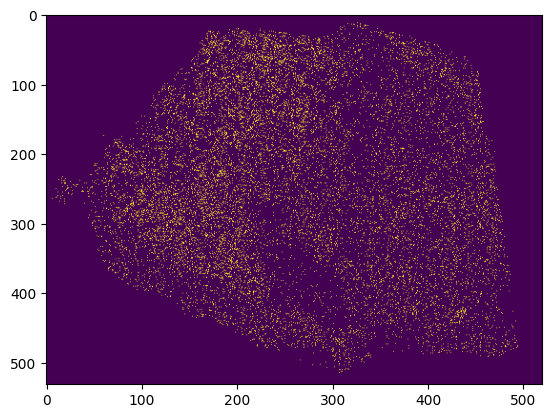

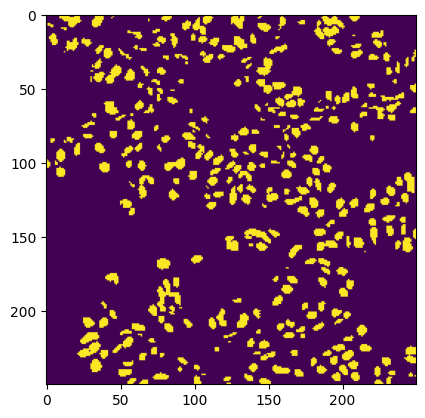

In [47]:
tpm = seg.get_total_pixel_matrix(combine_segments=True) # use 'combine_segments' as we only have one segment and don't need the third dimension

subregion = seg.get_total_pixel_matrix(row_start=5000, row_end=5250,
                                       column_start=5000, column_end=5250,
                                       combine_segments=True)

plt.imshow(tpm[::tpm.shape[0]//512, ::tpm.shape[1]//512], aspect='auto') # display downsampled TotalPixelMatrix
plt.show()

plt.imshow(subregion)
plt.show()

DICOM Segmentations reference the **source images**, i.e., the **slide** (`SeriesInstanceUID`) and specific **slide level** (`SOPInstanceUID`) that the segmentation was derived from. They can be obtained as follows:  

In [48]:
def get_referenced_uids(seg: hd.seg.Segmentation) -> Tuple[str]:
    (ref_study_uid, ref_series_uid, ref_sop_instance_uid) = seg.get_source_image_uids()[0]
    return ref_sop_instance_uid, ref_series_uid

ref_sop_instance_uid, ref_series_uid = get_referenced_uids(seg)
print(f'Source images SeriesInstanceUID: {ref_series_uid}')
print(f'Source images SOPInstanceUID: {ref_sop_instance_uid}')

Source images SeriesInstanceUID: 1.3.6.1.4.1.5962.99.1.1062471168.429178244.1637445043712.2.0
Source images SOPInstanceUID: 1.3.6.1.4.1.5962.99.1.1062471168.429178244.1637445043712.22.0


Note that a segmentation may not have been derived from any of the existing slide levels, but from a separately resampled one — in which case no slide level will match it. Downstream analysis of these cases will likely require resampling the slide to the pixel spacing of the segmentation mask.

The following code snippet can be used to quickly verify that a referenced slide level (`SOPInstanceUID`) is **spatially aligned** with the DICOM Segmentation.

In [49]:
idc_client.download_from_selection(sopInstanceUID=ref_sop_instance_uid, downloadDir='.', dirTemplate='%SeriesInstanceUID') # download referenced slide level
img = hd.imread(f'/content/{ref_series_uid}')

if seg.get_volume_geometry().geometry_equal(img.get_volume_geometry()):
    print('\n ✓ Spatial parameters match!')


 ✓ Spatial parameters match!


## Making use of the data: Preparing training pairs for neural networks

**Quick reminder**: the `Pan-Cancer-Nuclei-Seg-DICOM` collection contains two representations of the same data:
- polygon contours of the nuclei boundaries stored in DICOM Microscopy Bulk Simple Annotations (MBSA)
- binary masks of the segmented nuclei stored in DICOM Segmentations

The tutorial introducing the MBSA representation demonstrates how nuclei contours can be used to compute cellularity (or rather a nuclei-based proxy for cellularity). The same could also be done based on the binary segmentations, however, the main advantage of raster representations over vector representations is that they serve more naturally as input for neural networks. This notebook therefore focuses on **preparing pixel-level supervision for neural networks**.

In many computational pathology workflows, nuclei segmentations are used as training targets for supervised segmentation models. The image tile from the WSI is the model input, and the corresponding binary mask from the DICOM SEG is the target. This example does not train a useful model; it shows how to prepare a spatially aligned WSI and DICOM SEG as tensors that common deep learning frameworks can consume.

In [55]:
# Preparing paired image/mask tiles
TILE_SIZE = 256
NUM_EXAMPLE_TILES = 10

def get_image_tile(slide: 'WsiDicom', tile_coords: tuple[int, int], tile_size: int) -> np.ndarray:
    image = slide.read_region(tile_coords, size=(tile_size, tile_size), level=0)
    return np.asarray(image.convert('RGB'))

def get_seg_tile(seg: hd.seg.Segmentation, tile_coords: tuple[int, int], tile_size: int) -> np.ndarray:
    x0, y0 = tile_coords
    return seg.get_total_pixel_matrix(
        row_start=y0,
        row_end=y0 + tile_size,
        column_start=x0,
        column_end=x0 + tile_size,
        combine_segments=True,
        as_indices=True
    ).astype(np.float32)

def get_training_pair(slide: 'WsiDicom', seg: hd.seg.Segmentation, tile_coords: tuple[int, int], tile_size: int):
    image = get_image_tile(slide, tile_coords, tile_size)
    mask = get_seg_tile(seg, tile_coords, tile_size)
    return image, mask

In [57]:
def sample_training_pairs(slide: 'WsiDicom', seg: hd.seg.Segmentation, tile_size: int, num_tiles: int):
    """
    Collect up to `num_tiles` image/mask pairs that contain at least one nucleus.
    """

    candidate_coords = [
        (x, y)
        for y in range(0, seg.TotalPixelMatrixRows - tile_size + 1, tile_size)
        for x in range(0, seg.TotalPixelMatrixColumns - tile_size + 1, tile_size)
    ]
    random.shuffle(candidate_coords)

    training_pairs = []
    for tile_coords in candidate_coords:
        mask = get_seg_tile(seg, tile_coords, tile_size)
        if not mask.any():
            continue
        image = get_image_tile(slide, tile_coords, tile_size)
        training_pairs.append((tile_coords, image, mask))
        if len(training_pairs) == num_tiles:
            break

    if not training_pairs:
        raise RuntimeError('No non-empty nuclei mask tiles were found.'
                           'Try increasing TILE_SIZE or sampling a different slide region.')

    return training_pairs

slide = WsiDicom.open(f'/content/{ref_series_uid}')
training_pairs = sample_training_pairs(slide, seg, TILE_SIZE, NUM_EXAMPLE_TILES)
print(f'Collected {len(training_pairs)} non-empty image/mask pairs.')

Collected 10 non-empty image/mask pairs.


Each pair consists of an RGB tile from the referenced WSI and the corresponding binary nuclei mask read from the DICOM SEG. These arrays are already aligned because the SEG references the slide level and they passed the spatial consistency check above.

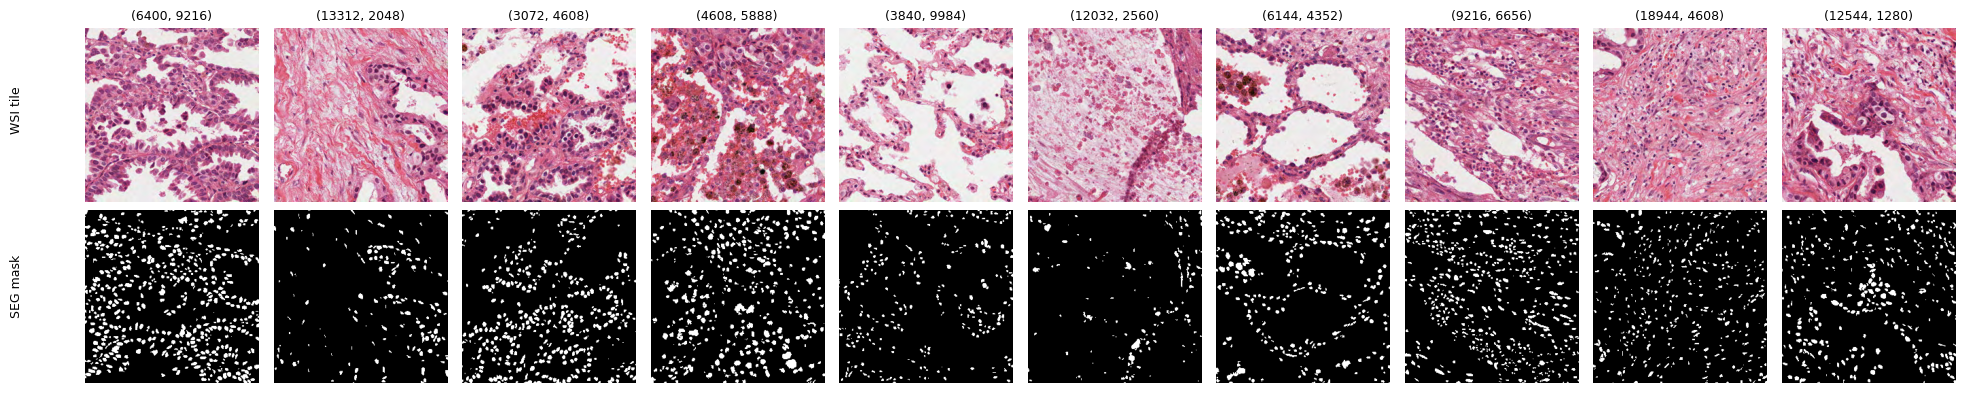

In [60]:
fig, axes = plt.subplots(2, len(training_pairs), figsize=(2 * len(training_pairs), 4), squeeze=False)

for i, (tile_coords, image, mask) in enumerate(training_pairs):
    axes[0, i].imshow(image)
    axes[0, i].set_title(f'{tile_coords}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].axis('off')

fig.text(0.02, 0.72, 'WSI tile', rotation=90, va='center', fontsize=9)
fig.text(0.02, 0.28, 'SEG mask', rotation=90, va='center', fontsize=9)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

For use with neural networks, the image tiles and masks are converted into tensors. The RGB WSI tile becomes the model input with shape `[3, height, width]`, and the DICOM SEG mask becomes the supervised target with shape `[1, height, width]`.

In [61]:
try:
    import torch
    import torch.nn as nn
except ImportError as exc:
    raise ImportError('PyTorch is required for this optional neural-network example.') from exc

image_batch = torch.stack([
    torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
    for _, image, _ in training_pairs
])
mask_batch = torch.stack([
    torch.from_numpy(mask).unsqueeze(0).float()
    for _, _, mask in training_pairs
])

print(f'Image batch shape: {image_batch.shape}')
print(f'Mask batch shape: {mask_batch.shape}')

Image batch shape: torch.Size([10, 3, 256, 256])
Mask batch shape: torch.Size([10, 1, 256, 256])


To verify that the pairs can be used in a neural-network workflow, we pass the image batch through a minimal convolutional model and compute a binary segmentation loss against the masks. In a real project, this placeholder model would be replaced by an architecture designed for nuclei segmentation, and the tiles would be split into training, validation, and test sets.

In [62]:
toy_model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 1, kernel_size=1),
)

prediction = toy_model(image_batch)
loss = nn.BCEWithLogitsLoss()(prediction, mask_batch)

print(f'Prediction shape: {prediction.shape}')
print(f'Target shape: {mask_batch.shape}')
print(f'Example segmentation loss: {loss.item():.4f}')

Prediction shape: torch.Size([10, 1, 256, 256])
Target shape: torch.Size([10, 1, 256, 256])
Example segmentation loss: 0.7084


This simple forward pass confirms that the DICOM Segmentations can be used as pixel-level supervision without converting the annotations through an intermediate non-DICOM format. The same pattern can be extended to larger tile datasets, by adding data augmentation, and model architectures commonly used for semantic or instance nuclei segmentation.

# Next steps
Share your feedback or ask questions about this notebook in IDC Forum: https://discourse.canceridc.dev.

If you are interested in tissue type annotations or want to learn about DICOM Structured Reporting, you can take a look at [this notebook](https://github.com/ImagingDataCommons/IDC-Tutorials/blob/master/notebooks/collections_demos/rms_mutation_prediction/RMS-Mutation-Prediction-Expert-Annotations_exploration.ipynb) navigating expert-generated region annotations for rhabdomyosarcoma tumor slides.



## Support

If you have any questions about this notebook, please post your question on the [IDC User Forum](https://discourse.canceridc.dev) or [open an issue](https://github.com/ImagingDataCommons/IDC-Tutorials/issues/new) in the [IDC Tutorials repository](https://github.com/ImagingDataCommons/IDC-Tutorials).

## Acknowledgments

Imaging Data Commons has been funded in whole or in part with Federal funds from the National Cancer Institute, National Institutes of Health, under Task Order No. HHSN26110071 under Contract No. HHSN261201500003I.

If you use IDC in your research, please cite the following publication:

> Fedorov, A., Longabaugh, W. J. R., Pot, D., Clunie, D. A., Pieper, S. D., Gibbs, D. L., Bridge, C., Herrmann, M. D., Homeyer, A., Lewis, R., Aerts, H. J. W., Krishnaswamy, D., Thiriveedhi, V. K., Ciausu, C., Schacherer, D. P., Bontempi, D., Pihl, T., Wagner, U., Farahani, K., Kim, E. & Kikinis, R. _National Cancer Institute Imaging Data Commons: Toward Transparency, Reproducibility, and Scalability in Imaging Artificial Intelligence_. RadioGraphics (2023). [https://doi.org/10.1148/rg.230180](https://doi.org/10.1148/rg.230180)